# Business Understanding

## Project Domain

Smart Energy Management / Building Energy Analytics
Proyek ini berada di ranah pengelolaan energi cerdas untuk bangunan, dengan fokus pada pemantauan dan analisis konsumsi energi berdasarkan berbagai faktor seperti cuaca, luas bangunan, tingkat hunian, dan penggunaan sistem HVAC dan pencahayaan.

  

## Problem Statements

Banyak bangunan tidak memiliki sistem analitik cerdas untuk mengidentifikasi faktor-faktor yang menyebabkan konsumsi energi tinggi.

Kurangnya pemanfaatan data historis untuk prediksi konsumsi energi menyebabkan inefisiensi dalam perencanaan energi.

Penggunaan energi terbarukan belum dioptimalkan berdasarkan pola konsumsi aktual.

Tidak ada sistem prediksi otomatis yang dapat memberi rekomendasi penghematan energi secara real-time.

## Goals

Menganalisis faktor-faktor yang mempengaruhi konsumsi energi (suhu, kelembaban, occupancy, hari libur, dll).

Membangun model prediksi konsumsi energi berdasarkan data historis.

Mengidentifikasi peran energi terbarukan dan optimasi penggunaannya.

Memberikan insight yang dapat digunakan untuk pengambilan keputusan efisiensi energi.

  

## Solution Statements

Menggunakan machine learning untuk memprediksi konsumsi energi berdasarkan fitur seperti suhu, kelembaban, occupancy, penggunaan HVAC dan lighting.

Mengembangkan dashboard visualisasi untuk menunjukkan pola konsumsi energi harian/mingguan.

Menyediakan sistem peringatan dini untuk mendeteksi anomali konsumsi energi.

Menilai kontribusi energi terbarukan terhadap total konsumsi dan memberikan rekomendasi peningkatan efisiensi.

# Data Understanding

## Import data dari kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"anggaraagustianti","key":"b5f366aab8788b57a7d428f54d3edb05"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [4]:
!kaggle datasets download -d mrsimple07/energy-consumption-prediction


Dataset URL: https://www.kaggle.com/datasets/mrsimple07/energy-consumption-prediction
License(s): apache-2.0


In [5]:
!mkdir energy-consumption-prediction
!unzip energy-consumption-prediction.zip -d energy-consumption-prediction
!ls energy-consumption-prediction


Archive:  energy-consumption-prediction.zip
  inflating: energy-consumption-prediction/Energy_consumption.csv  
Energy_consumption.csv


In [6]:
!kaggle datasets download -d mrsimple07/energy-consumption-prediction
!unzip energy-consumption-prediction .zip


Dataset URL: https://www.kaggle.com/datasets/mrsimple07/energy-consumption-prediction
License(s): apache-2.0
energy-consumption-prediction.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  energy-consumption-prediction.zip
caution: filename not matched:  .zip


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense


import pickle


**. Data Preparation

In [14]:


for root, dirs, files in os.walk("energy-consumption-prediction"):
    for file in files:
        print(os.path.join(root, file))


energy-consumption-prediction/Energy_consumption.csv


In [17]:


df = pd.read_csv("/content/energy-consumption-prediction/Energy_consumption.csv")  # Ganti dengan nama file CSV kamu


# Lihat struktur data
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          1000 non-null   object 
 1   Temperature        1000 non-null   float64
 2   Humidity           1000 non-null   float64
 3   SquareFootage      1000 non-null   float64
 4   Occupancy          1000 non-null   int64  
 5   HVACUsage          1000 non-null   object 
 6   LightingUsage      1000 non-null   object 
 7   RenewableEnergy    1000 non-null   float64
 8   DayOfWeek          1000 non-null   object 
 9   Holiday            1000 non-null   object 
 10  EnergyConsumption  1000 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 86.1+ KB
None
             Timestamp  Temperature   Humidity  SquareFootage  Occupancy  \
0  2022-01-01 00:00:00    25.139433  43.431581    1565.693999          5   
1  2022-01-01 01:00:00    27.731651  54.225919    

## Exploratory Data Analysis

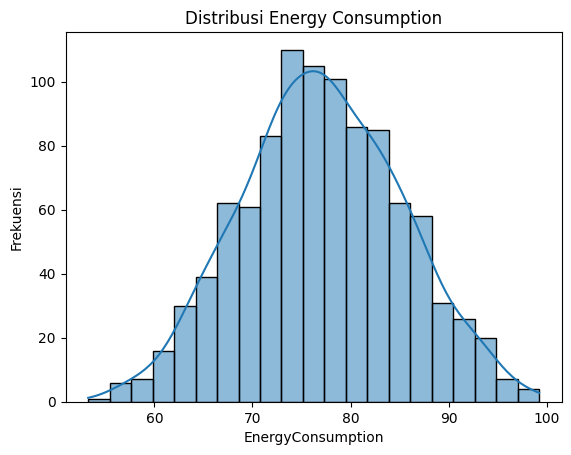

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["EnergyConsumption"], kde=True)
plt.title("Distribusi Energy Consumption")
plt.xlabel("EnergyConsumption")
plt.ylabel("Frekuensi")
plt.show()


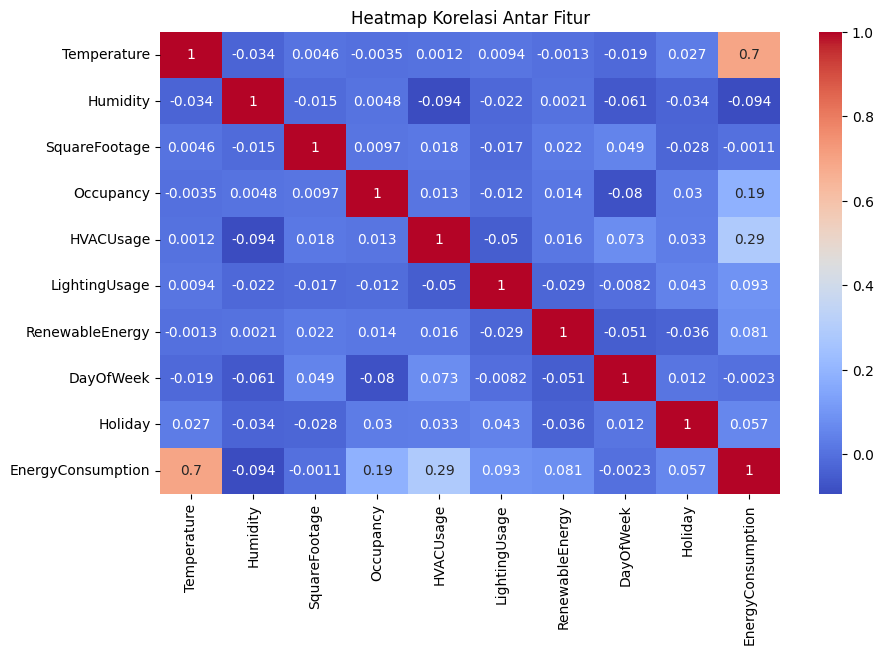

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Heatmap Korelasi Antar Fitur")
plt.show()


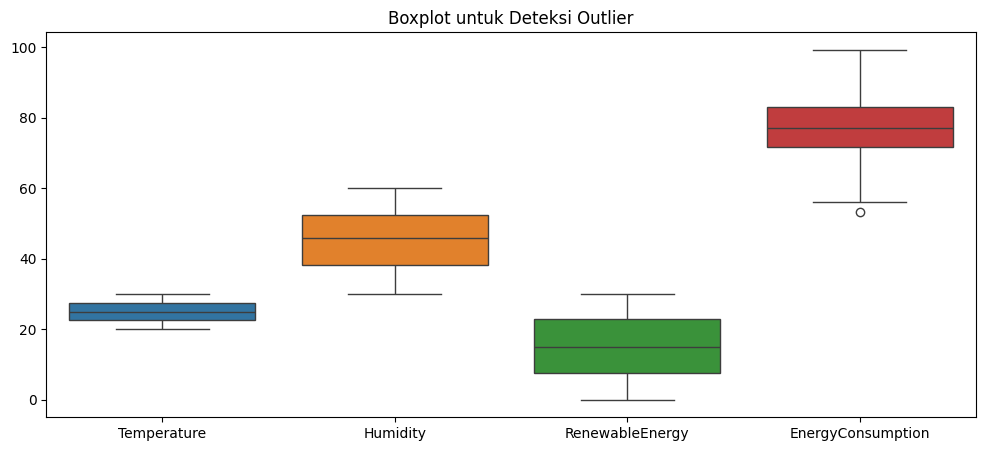

In [ ]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[["Temperature", "Humidity", "RenewableEnergy", "EnergyConsumption"]])
plt.title("Boxplot untuk Deteksi Outlier")
plt.show()


<ipython-input-53-0a92a0ee0944>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="DayOfWeek", y="EnergyConsumption", data=df_temp, ci=None)


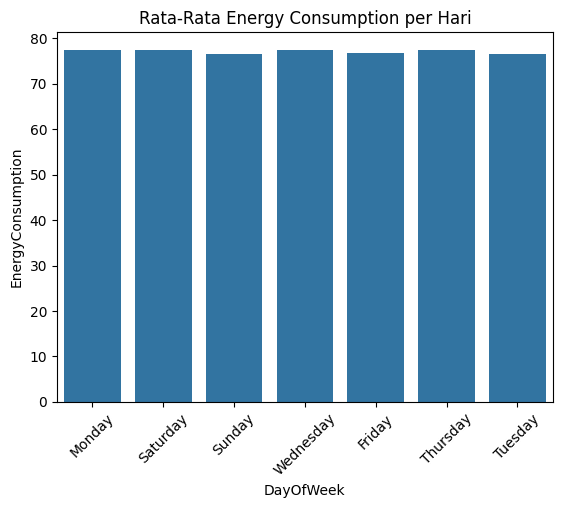

In [ ]:
df_temp = df.copy()
df_temp["DayOfWeek"] = label_encoders["DayOfWeek"].inverse_transform(df_temp["DayOfWeek"])
sns.barplot(x="DayOfWeek", y="EnergyConsumption", data=df_temp, ci=None)
plt.title("Rata-Rata Energy Consumption per Hari")
plt.xticks(rotation=45)
plt.show()


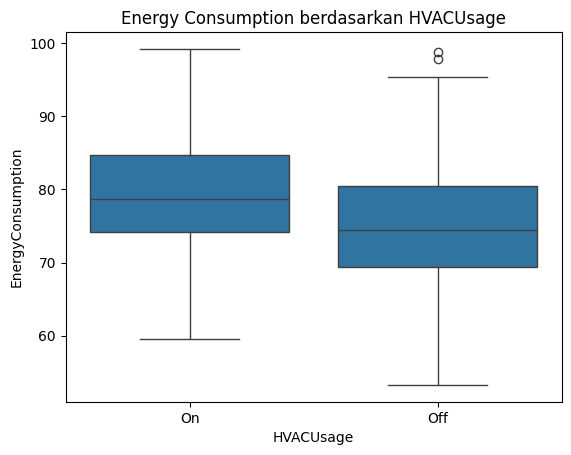

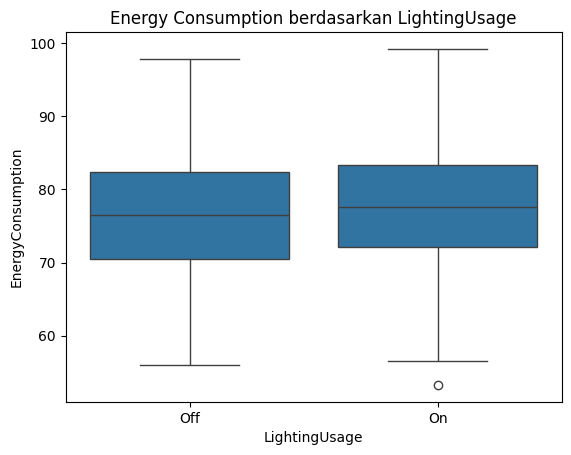

In [ ]:
df_temp["HVACUsage"] = label_encoders["HVACUsage"].inverse_transform(df_temp["HVACUsage"])
df_temp["LightingUsage"] = label_encoders["LightingUsage"].inverse_transform(df_temp["LightingUsage"])

sns.boxplot(x="HVACUsage", y="EnergyConsumption", data=df_temp)
plt.title("Energy Consumption berdasarkan HVACUsage")
plt.show()

sns.boxplot(x="LightingUsage", y="EnergyConsumption", data=df_temp)
plt.title("Energy Consumption berdasarkan LightingUsage")
plt.show()


# Modeling

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])


model.compile(optimizer='adam', loss='mse', metrics=['mae'])


model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5955.3179 - mae: 76.7584 - val_loss: 5782.9438 - val_mae: 75.5435
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5790.9390 - mae: 75.6589 - val_loss: 5486.5483 - val_mae: 73.5495
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5380.5601 - mae: 72.9082 - val_loss: 5064.1748 - val_mae: 70.6075
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5003.8594 - mae: 70.2014 - val_loss: 4480.4106 - val_mae: 66.3313
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4374.4365 - mae: 65.5571 - val_loss: 3723.0996 - val_mae: 60.3369
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3506.4038 - mae: 58.5380 - val_loss: 2821.1646 - val_mae: 52.2895
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2578.3269 - mae: 49.8160 - val_loss: 1877.1907 - val_mae: 42.2482
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1676.7562 - mae: 39.6096 - val_loss: 1048.5243 - val_mae: 30.8546
Epoch 9/100

# Evaluation

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
📊 R² Score       : 0.3807 (Target ≥ 0.90)
📉 MAE (Mean Abs) : 5.1554
📉 RMSE           : 6.3688


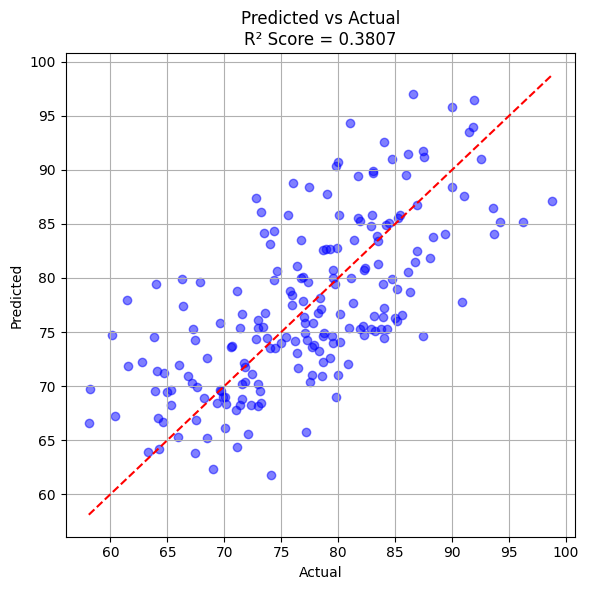

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# Prediksi hasil dari model
y_pred = model.predict(X_test).flatten()

# Evaluasi metrik regresi
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Cetak hasil evaluasi
print(f"📊 R² Score       : {r2:.4f} (Target ≥ 0.90)")
print(f"📉 MAE (Mean Abs) : {mae:.4f}")
print(f"📉 RMSE           : {rmse:.4f}")

# Visualisasi Prediksi vs Aktual
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Predicted vs Actual\nR² Score = {r2:.4f}")
plt.grid(True)
plt.tight_layout()
plt.show()


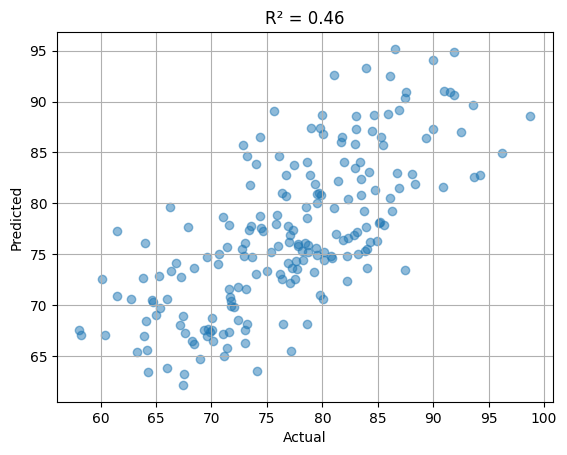

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"R² = {r2:.2f}")
plt.grid(True)
plt.show()


# Deployment

## Model Simulation

In [1]:
# Simpan model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open("model_energy.tflite", "wb") as f:
    f.write(tflite_model)


NameError: name 'tf' is not defined

In [ ]:
import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoders, f)


## Save Model

In [ ]:
# Simpan model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open("model_energy.tflite", "wb") as f:
    f.write(tflite_model)


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 5989.5122 - mae: 77.0055 - val_loss: 5831.8652 - val_mae: 75.8752
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5827.0830 - mae: 75.9101 - val_loss: 5621.6226 - val_mae: 74.4571
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5485.8877 - mae: 73.6085 - val_loss: 5314.4087 - val_mae: 72.3411
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5154.3970 - mae: 71.2772 - val_loss: 4852.3691 - val_mae: 69.0455
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4741.6411 - mae: 68.3074 - val_loss: 4206.4512 - val_mae: 64.1481
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3975.0723 - mae: 62.3569 - val_loss: 3386.5776 - val_mae: 57.3207
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3194.7754 - mae: 55.6450 - val_loss: 2459.9775 - val_mae: 48.4624
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2196.2654 - mae: 45.7913 - val_loss: 1559.8926 - val_mae: 37.8680
Epoch 9